<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/encoding/encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [10]:
df=pd.read_csv("/content/drive/MyDrive/AI-python/lecture12/titanic_train_data.csv")

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df_after_dropping = df.drop(columns=["SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked"])

In [13]:
df_after_dropping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
dtypes: float64(1), int64(3), object(2)
memory usage: 41.9+ KB


In [15]:
missing_count = df_after_dropping.isna().sum()
print(missing_count)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
dtype: int64


In [16]:
df_after_dropping["Age"] = df_after_dropping["Age"].fillna(df_after_dropping["Age"].mean())

In [17]:
missing_count_again = df_after_dropping.isna().sum()
print(missing_count_again)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
dtype: int64


/tmp/ipython-input-2586478194.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_age = df_after_dropping.groupby(age_bins)["Survived"].mean()


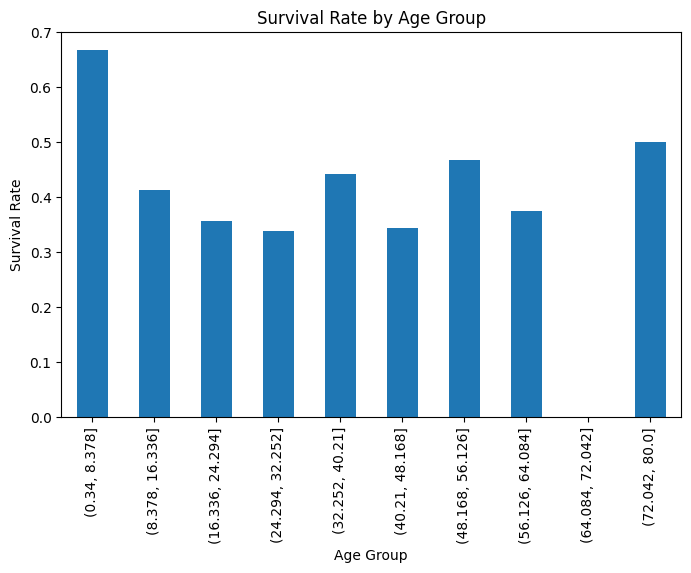

In [19]:
age_bins = pd.cut(df_after_dropping["Age"], bins=10)
survival_by_age = df_after_dropping.groupby(age_bins)["Survived"].mean()
plt.figure(figsize=(8, 5))
survival_by_age.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.show()

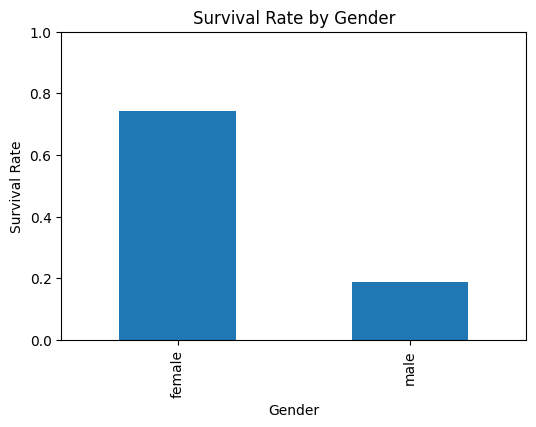

In [20]:
survival_by_gender = df_after_dropping.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(6, 4))
survival_by_gender.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

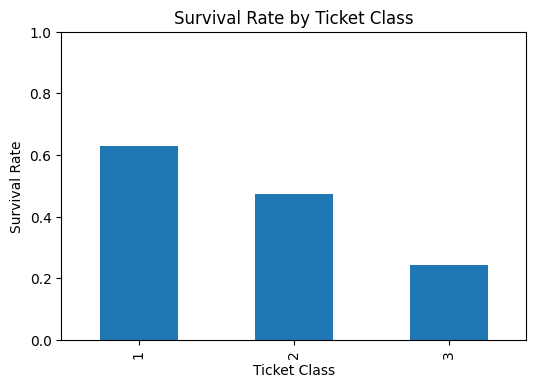

In [21]:
survival_by_class = df_after_dropping.groupby("Pclass")["Survived"].mean()
plt.figure(figsize=(6, 4))
survival_by_class.plot(kind="bar")
plt.title("Survival Rate by Ticket Class")
plt.xlabel("Ticket Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

In [22]:
print("Original DataFrame:")
print(df)
print("\n")

Original DataFrame:
     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                               

In [23]:
le = LabelEncoder()
df['Sex_Encoded'] = le.fit_transform(df['Sex'])
df['Ticket_Encoded'] = le.fit_transform(df['Ticket'])
df['Pclass_Encoded'] = le.fit_transform(df['Pclass'])


In [24]:
print("DataFrame after Label Encoding:")
df

DataFrame after Label Encoding:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_Encoded,Ticket_Encoded,Pclass_Encoded
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,523,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,596,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,669,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,49,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,472,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,101,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,14,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,675,2
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1,8,0


<Axes: >

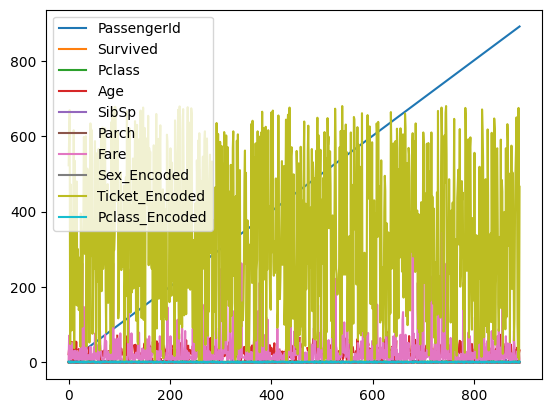

In [25]:
df.plot()